# IPL Model Training — Multi-Model Benchmark (Model A+)

Extends `IPL_Model_Training_ModelA.ipynb`. Trains and compares **many classical ML models** on the handcrafted per-cell features in `features.csv`, picks the best by **group-aware cross-validated macro-F1**, and exports it as `model_<teamname>.pkl` plus the project's prediction CSV.

**Models benchmarked**
- Gradient-boosted trees: **XGBoost, LightGBM, CatBoost, HistGradientBoosting**
- Bagged trees: **Random Forest, Extra Trees**
- **SVM (RBF) + PCA**
- Linear / margin: **Logistic Regression**, **Linear SVM**
- Distance / probabilistic: **KNN**
- A **soft-voting ensemble** of the strongest few
- (optional) a **two-stage** model: "is there a team?" then "which team?"

No deep learning / neural nets — all classical, hand-crafted-feature models, per the project rules.

**Why the metric choice matters here.** The grid is dominated by label `0` (No Team) — usually 80%+ of cells. Plain **accuracy is misleading** (a model predicting all-zeros scores high). So the primary metric is **macro-F1** (every team weighted equally), evaluated with **group-aware CV** (all 64 cells of an image stay in the same fold — no leakage). Weighted metrics and per-class reports are shown alongside.


## 0. Install (only the extras not already in your env)

In [2]:
# Your pyproject already has xgboost, scikit-learn, pandas, numpy.
# These two are the new gradient-boosting libraries:
!uv pip install lightgbm catboost optuna

Using Python 3.13.9 environment at: /Users/nikhiljha/Desktop/ipl-team-detection/.venv
Checked 3 packages in 44ms


## 1. Imports

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib, warnings, time
warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAVE_LGBM = True
except Exception as e:
    HAVE_LGBM = False; print("LightGBM unavailable:", e)
try:
    from catboost import CatBoostClassifier
    HAVE_CAT = True
except Exception as e:
    HAVE_CAT = False; print("CatBoost unavailable:", e)

import matplotlib.pyplot as plt
import seaborn as sns
RANDOM_STATE = 42

# --- lightweight progress helpers (so long cells show they're working) ------
import sys, time as _time
from contextlib import contextmanager

@contextmanager
def step(msg):
    # Print 'msg ...' then 'msg done (Ns)' around a block, flushing live.
    print(f"⏳ {msg} ...", end="", flush=True)
    t0 = _time.time()
    try:
        yield
    finally:
        print(f"\r✅ {msg} — done in {_time.time()-t0:.1f}s" + " "*8, flush=True)

def progress(i, n, label=""):
    # One-line live counter: [ 3/10] label.
    print(f"\r   [{i:>3}/{n}] {label:<28}", end="", flush=True)
    if i == n:
        print()

TEAM_MAP = {0:'No Team',1:'CSK',2:'DC',3:'GT',4:'KKR',5:'LSG',
            6:'MI',7:'PBKS',8:'RR',9:'RCB',10:'SRH'}


## 2. Load features

In [3]:
DATA_DIR = Path("../data")                 # adjust if needed; print resolves it
FEATURE_FILE = DATA_DIR / "features.csv"
print("Reading:", FEATURE_FILE.resolve())
df = pd.read_csv(FEATURE_FILE)
print("Shape:", df.shape)
df.head()


Reading: /Users/nikhiljha/Desktop/ipl-team-detection/data/features.csv
Shape: (230720, 679)


,image_name,cell_id,label,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_667,f_668,f_669,f_670,f_671,f_672,f_673,f_674,f_675,f_676
0,GTvsLSG_image_0.jpg,1,0,0.819521,0.273765,0.267433,0.419384,0.057488,0.051157,0.010637,...,0.037274,0.029713,0.090555,0.213707,0.275448,0.275448,0.141855,0.093850,0.041015,0.020408
1,GTvsLSG_image_0.jpg,2,0,0.007270,0.100509,0.512661,0.542688,0.515190,0.195962,0.195330,...,0.055488,0.307377,0.084778,0.045963,0.056343,0.064856,0.095264,0.105586,0.182372,0.307377
2,GTvsLSG_image_0.jpg,3,0,0.000000,0.042769,0.142231,0.323585,0.794706,0.330879,0.268880,...,0.066395,0.046282,0.010631,0.023346,0.081757,0.291008,0.240174,0.291008,0.291008,0.125004
3,GTvsLSG_image_0.jpg,4,0,0.093658,0.460096,0.391803,0.332096,0.277462,0.178731,0.353169,...,0.035454,0.080711,0.136827,0.293666,0.293666,0.202032,0.078363,0.044881,0.019489,0.006625
4,GTvsLSG_image_0.jpg,5,0,0.243183,0.841610,0.473506,0.079453,0.028934,0.025030,0.022504,...,0.074625,0.230121,0.166748,0.114429,0.033296,0.089340,0.106698,0.107236,0.129191,0.106516


## 3. Features, labels, groups

In [4]:
feature_cols = [c for c in df.columns if c.startswith("f_")]
X = df[feature_cols].values
y = df["label"].astype(int).values
groups = df["image_name"].values           # keep all cells of an image together

print(f"Features: {X.shape}  |  classes present: {sorted(np.unique(y))}")
print(f"Images:   {pd.Series(groups).nunique()}")

# NaN/inf guard (skew/correlation features can produce these on flat cells)
bad = ~np.isfinite(X)
if bad.any():
    print(f"Replacing {bad.sum()} non-finite feature values with 0.")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)


Features: (230720, 676)  |  classes present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Images:   3605


## 4. The imbalance problem — see it first

If `0` (No Team) dominates, accuracy is the wrong headline metric. This cell shows the class balance so the metric choice below is justified.

 label    team  count   pct
     0 No Team 192851 83.59
     1     CSK   3292  1.43
     2      DC   1991  0.86
     3      GT   2484  1.08
     4     KKR   4735  2.05
     5     LSG   2554  1.11
     6      MI   5863  2.54
     7    PBKS   3839  1.66
     8      RR   2844  1.23
     9     RCB   3426  1.48
    10     SRH   6841  2.97

Majority class share: 83.6%  (a trivial all-zeros model would score ~this as 'accuracy')


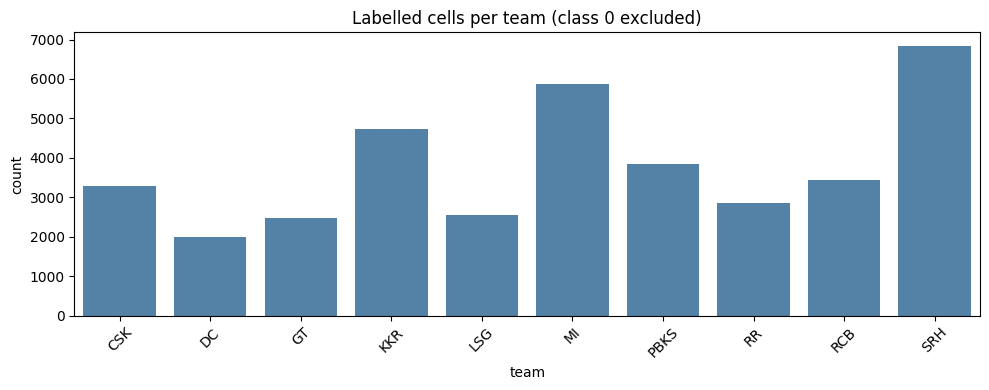

In [5]:
counts = pd.Series(y).value_counts().sort_index()
dist = pd.DataFrame({"label": counts.index,
                     "team": [TEAM_MAP[i] for i in counts.index],
                     "count": counts.values})
dist["pct"] = (100 * dist["count"] / dist["count"].sum()).round(2)
print(dist.to_string(index=False))
print(f"\nMajority class share: {dist['pct'].max():.1f}%  "
      f"(a trivial all-zeros model would score ~this as 'accuracy')")

plt.figure(figsize=(10,4))
sns.barplot(data=dist[dist.label!=0], x="team", y="count", color="steelblue")
plt.title("Labelled cells per team (class 0 excluded)"); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


## 5. Image-aware split (holdout) + CV splitter

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train = groups[train_idx]
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train images:", pd.Series(g_train).nunique(),
      " Test images:", pd.Series(groups[test_idx]).nunique())

# class weights (for models that accept them) to counter imbalance
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
# xgboost/lgbm sample-weight version
sw_train = np.array([class_weight[int(c)] for c in y_train])
print("class weights:", {TEAM_MAP[k]: round(v,2) for k,v in class_weight.items()})

N_CV_SPLITS = min(4, pd.Series(g_train).nunique())   # group-aware CV folds
gkf = GroupKFold(n_splits=N_CV_SPLITS)


Train: (184576, 676)  Test: (46144, 676)
Train images: 2884  Test images: 721
class weights: {'No Team': 0.11, 'CSK': 6.44, 'DC': 10.1, 'GT': 8.75, 'KKR': 4.37, 'LSG': 8.26, 'MI': 3.64, 'PBKS': 5.57, 'RR': 7.55, 'RCB': 6.07, 'SRH': 3.01}


## 6. Define the model zoo

Each entry is a ready-to-fit estimator. Tree models get `class_weight='balanced'` where supported; boosters get sample weights at fit time. SVM/KNN/LogReg are wrapped with scaling (and PCA for the RBF SVM, which is slow on raw high-dim features).

In [7]:
num_classes = len(np.unique(y))

def make_models():
    m = {}
    m["RandomForest"] = RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
    m["ExtraTrees"] = ExtraTreesClassifier(
        n_estimators=500, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE)
    m["HistGB"] = HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.08, max_depth=None,
        l2_regularization=1.0, random_state=RANDOM_STATE)
    m["XGBoost"] = XGBClassifier(
        objective="multi:softprob", num_class=num_classes, n_estimators=500,
        max_depth=8, learning_rate=0.07, subsample=0.85, colsample_bytree=0.85,
        eval_metric="mlogloss", tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE)
    if HAVE_LGBM:
        m["LightGBM"] = LGBMClassifier(
            n_estimators=600, learning_rate=0.05, num_leaves=63,
            subsample=0.85, colsample_bytree=0.85, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
    if HAVE_CAT:
        m["CatBoost"] = CatBoostClassifier(
            iterations=600, learning_rate=0.05, depth=8, loss_function="MultiClass",
            auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=0)
    m["SVM_RBF_PCA"] = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale",
                    class_weight="balanced", probability=True,
                    random_state=RANDOM_STATE))])
    m["LinearSVM"] = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(C=1.0, class_weight="balanced",
                          random_state=RANDOM_STATE, max_iter=5000))])
    m["LogReg"] = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  n_jobs=-1,
                                  random_state=RANDOM_STATE))])
    m["KNN"] = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1))])
    return m

def fit_one(name, model, Xtr, ytr, sw):
    # pass sample_weight to boosters that don't take class_weight
    if name in ("XGBoost", "HistGB"):
        try: model.fit(Xtr, ytr, sample_weight=sw); return model
        except TypeError: pass
    model.fit(Xtr, ytr); return model

print("Models:", list(make_models().keys()))


Models: ['RandomForest', 'ExtraTrees', 'HistGB', 'XGBoost', 'LightGBM', 'CatBoost', 'SVM_RBF_PCA', 'LinearSVM', 'LogReg', 'KNN']


## 7. Group-aware cross-validation (primary comparison)

For each model we get out-of-fold predictions via `GroupKFold`, so every metric is on data the model didn't train on, and no image straddles folds. **Macro-F1 is the headline.**

In [8]:
def metrics_row(name, yt, yp, secs):
    return {"Model": name,
            "macroF1": f1_score(yt, yp, average="macro", zero_division=0),
            "balAcc":  balanced_accuracy_score(yt, yp),
            "weightedF1": f1_score(yt, yp, average="weighted", zero_division=0),
            "accuracy": accuracy_score(yt, yp),
            "precision_w": precision_score(yt, yp, average="weighted", zero_division=0),
            "recall_w": recall_score(yt, yp, average="weighted", zero_division=0),
            "fit_sec": round(secs, 1)}

cv_rows = []
def _cvp_with_weight(model, X, y, groups, cv, sw):
    # sklearn renamed fit_params -> params in 1.6; support both.
    try:
        return cross_val_predict(model, X, y, groups=groups, cv=cv, n_jobs=1,
                                 params={"sample_weight": sw})
    except TypeError:
        return cross_val_predict(model, X, y, groups=groups, cv=cv, n_jobs=1,
                                 fit_params={"sample_weight": sw})

_all = make_models()
print(f"Cross-validating {len(_all)} models over {N_CV_SPLITS} group-folds "
      f"(slow models like SVM_RBF_PCA can take several minutes)...\n")
_t_cv = time.time()
for _k, (name, model) in enumerate(_all.items(), 1):
    print(f"▶ [{_k}/{len(_all)}] {name}: training across {N_CV_SPLITS} folds ...",
          end="", flush=True)
    t0 = time.time()
    try:
        if name in ("XGBoost", "HistGB"):
            yp = _cvp_with_weight(model, X_train, y_train, g_train, gkf, sw_train)
        else:
            yp = cross_val_predict(model, X_train, y_train, groups=g_train, cv=gkf, n_jobs=1)
        cv_rows.append(metrics_row(name, y_train, yp, time.time()-t0))
        print(f"\r✅ [{_k}/{len(_all)}] {name:14s} macroF1={cv_rows[-1]['macroF1']:.4f}  "
              f"balAcc={cv_rows[-1]['balAcc']:.4f}  ({cv_rows[-1]['fit_sec']}s)" + " "*10)
    except Exception as e:
        print(f"\r❌ [{_k}/{len(_all)}] {name:14s} FAILED: {e}" + " "*10)

print(f"\nAll models cross-validated in {time.time()-_t_cv:.1f}s total.")
cv_df = pd.DataFrame(cv_rows).sort_values("macroF1", ascending=False).reset_index(drop=True)
print("\n=== Cross-validated leaderboard (sorted by macro-F1) ===")
cv_df.round(4)


Cross-validating 10 models over 4 group-folds (slow models like SVM_RBF_PCA can take several minutes)...

✅ [1/10] RandomForest   macroF1=0.4459  balAcc=0.3337  (1273.4s)          
✅ [2/10] ExtraTrees     macroF1=0.2580  balAcc=0.1919  (407.5s)          
✅ [3/10] HistGB         macroF1=0.5442  balAcc=0.7535  (634.5s)          
✅ [4/10] XGBoost        macroF1=0.6601  balAcc=0.6338  (4779.2s)          
✅ [5/10] LightGBM       macroF1=0.6571  balAcc=0.6099  (3656.2s)          
✅ [6/10] CatBoost       macroF1=0.5184  balAcc=0.7542  (8957.4s)          
▶ [7/10] SVM_RBF_PCA: training across 4 folds ...

: 

: 

## 8. Visual leaderboard

NameError: name 'cv_df' is not defined

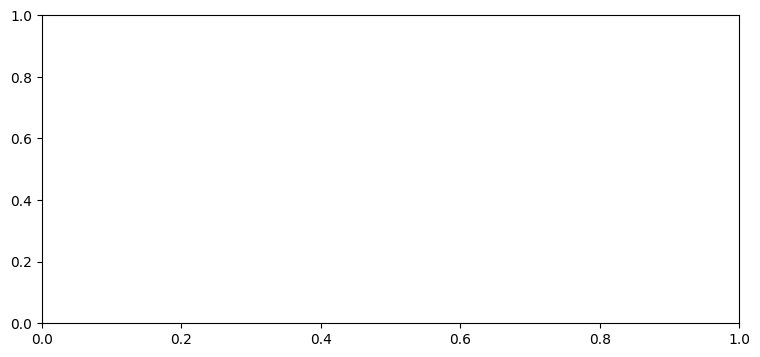

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
order = cv_df.sort_values("macroF1")
ax.barh(order["Model"], order["macroF1"], color="seagreen")
for i, v in enumerate(order["macroF1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("Cross-validated macro-F1"); ax.set_title("Model comparison (higher = better)")
plt.tight_layout(); plt.show()
cv_df.round(4)


## 9. Refit top models on full train, evaluate on holdout

The CV leaderboard chooses; the holdout (untouched 20% of images) confirms. We refit the top 3 and a soft-voting ensemble of them.

In [ ]:
TOP_K = 3
top_names = cv_df["Model"].head(TOP_K).tolist()
print("Top models:", top_names)

fitted = {}
zoo = make_models()
for name in top_names:
    with step(f"Refitting {name} on full train"):
        fitted[name] = fit_one(name, zoo[name], X_train, y_train, sw_train)

# soft-voting ensemble of the probability-capable top models
prob_capable = [n for n in top_names
                if n not in ("LinearSVM",)]   # LinearSVC has no predict_proba
if len(prob_capable) >= 2:
    ens = VotingClassifier(
        estimators=[(n, make_models()[n]) for n in prob_capable],
        voting="soft", n_jobs=1)
    with step("Fitting soft-voting ensemble of top models"):
        fitted["Voting(top)"] = fit_one("Voting", ens, X_train, y_train, sw_train)

holdout = []
for name, model in fitted.items():
    with step(f"Scoring {name} on holdout"):
        yp = model.predict(X_test)
    holdout.append(metrics_row(name, y_test, yp, 0))
hold_df = pd.DataFrame(holdout).sort_values("macroF1", ascending=False).reset_index(drop=True)
print("\n=== Holdout performance ===")
hold_df.round(4)


## 10. Best model: confusion matrix + per-class report

In [ ]:
best_name = hold_df.iloc[0]["Model"]
best_model = fitted[best_name]
print("BEST:", best_name)

yp = best_model.predict(X_test)
print(classification_report(y_test, yp,
      target_names=[TEAM_MAP[i] for i in sorted(np.unique(y))], zero_division=0))

labels_sorted = sorted(np.unique(y))
cm = confusion_matrix(y_test, yp, labels=labels_sorted)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[TEAM_MAP[i] for i in labels_sorted],
            yticklabels=[TEAM_MAP[i] for i in labels_sorted])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()


## 11. (Optional) Two-stage model — detection then team-ID

Because class 0 dominates, a sometimes-stronger approach is: **Stage 1** binary classifier (team vs no-team), then **Stage 2** multiclass classifier (1–10) trained only on real-team cells. Run this to see if it beats the single-stage best on macro-F1.

In [ ]:
# Stage 1: is this cell a team at all?
y_bin_train = (y_train > 0).astype(int)
stage1 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                        random_state=RANDOM_STATE)
stage1.fit(X_train, y_bin_train, sample_weight=np.where(y_bin_train==1,
           (y_bin_train==0).sum()/max(1,(y_bin_train==1).sum()), 1.0))

# Stage 2: which team, trained on team-only cells
mask = y_train > 0
stage2 = XGBClassifier(objective="multi:softprob", num_class=num_classes,
                       n_estimators=500, max_depth=8, learning_rate=0.07,
                       subsample=0.85, colsample_bytree=0.85, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
stage2.fit(X_train[mask], y_train[mask])

# Inference: predict team only where stage1 says "team"
is_team = stage1.predict(X_test).astype(bool)
two_stage_pred = np.zeros(len(X_test), dtype=int)
if is_team.any():
    two_stage_pred[is_team] = stage2.predict(X_test[is_team])

ts = metrics_row("TwoStage(HGB+XGB)", y_test, two_stage_pred, 0)
print("Two-stage holdout:  macroF1=%.4f  balAcc=%.4f  weightedF1=%.4f"
      % (ts["macroF1"], ts["balAcc"], ts["weightedF1"]))
print("Single-stage best:  macroF1=%.4f  (%s)" % (hold_df.iloc[0]["macroF1"], best_name))

# adopt two-stage if it wins on macro-F1
if ts["macroF1"] > hold_df.iloc[0]["macroF1"]:
    print("-> Two-stage wins; wrapping it as the best model.")
    class TwoStage:
        def __init__(self, s1, s2): self.s1, self.s2 = s1, s2
        def predict(self, X):
            X = np.nan_to_num(np.asarray(X, float))
            m = self.s1.predict(X).astype(bool)
            out = np.zeros(len(X), dtype=int)
            if m.any(): out[m] = self.s2.predict(X[m])
            return out
    best_model = TwoStage(stage1, stage2); best_name = "TwoStage(HGB+XGB)"
else:
    print("-> Single-stage best is retained.")


## 12. Save best model as `model_<teamname>.pkl`

In [ ]:
TEAM_NAME = "teamname"        # <-- replace with your actual team name
model_file = Path(f"model_{TEAM_NAME}.pkl")
joblib.dump(best_model, model_file)
print(f"Saved best model ({best_name}) -> {model_file.resolve()}")


## 13. Produce the project's predictions CSV

The deliverable format is one row per image: `Image File Name, Train Or Test, c01 … c64`. This runs the best model over every cell and pivots the per-cell predictions back to the wide grid layout.

In [ ]:
with step("Predicting every cell in the dataset"):
    pred_all = best_model.predict(X)        # predict every cell
out = df[["image_name", "cell_id"]].copy()
out["pred"] = pred_all
out["split"] = "Train"
out.loc[np.isin(np.arange(len(df)), test_idx), "split"] = "Test"

# pivot to wide c01..c64
wide = out.pivot_table(index=["image_name", "split"], columns="cell_id",
                       values="pred", aggfunc="first").reset_index()
wide.columns = (["Image File Name", "Train Or Test"] +
                [f"c{int(c):02d}" for c in wide.columns[2:]])
# ensure all 64 columns exist and ordered
for i in range(1, 65):
    col = f"c{i:02d}"
    if col not in wide.columns: wide[col] = 0
wide = wide[["Image File Name", "Train Or Test"] + [f"c{i:02d}" for i in range(1,65)]]
wide.iloc[:, 2:] = wide.iloc[:, 2:].fillna(0).astype(int)

pred_csv = Path("predictions.csv")
wide.to_csv(pred_csv, index=False)
print("Wrote", pred_csv.resolve(), "shape", wide.shape)
wide.head()


## 14. Feature-group importance — which feature *families* matter?

Your features are concatenated in a fixed order: RGB hist, HSV hist, colour moments, LBP, GLCM, Canny, HOG. This tells you which **families** carry the signal — far more actionable than 676 individual `f_*` bars. Two views:

- **Native importance** (tree models): sum the model's per-feature importances within each family.
- **Group-permutation importance** (model-agnostic, the honest one): shuffle an entire family's columns in the holdout and measure the **macro-F1 drop**. Big drop = the model leans on that family.

In [ ]:
# Feature-family boundaries (must match extract_features() order in your EDA notebook).
# First six families have fixed lengths; HOG takes the remainder.
FIXED_GROUPS = [("RGB hist", 48), ("HSV hist", 48), ("Colour moments", 9),
                ("LBP", 10), ("GLCM", 4), ("Canny", 17)]
n_feat = X.shape[1]
fixed_total = sum(n for _, n in FIXED_GROUPS)
groups_def, start = [], 0
for gname, glen in FIXED_GROUPS:
    groups_def.append((gname, list(range(start, start + glen)))); start += glen
if n_feat > fixed_total:
    groups_def.append(("HOG", list(range(fixed_total, n_feat))))
elif n_feat != fixed_total:
    print(f"WARNING: feature count {n_feat} != expected {fixed_total}+HOG. "
          f"Adjust FIXED_GROUPS to match your extractor.")
print("Feature families:", [(g, len(idx)) for g, idx in groups_def], " total:", n_feat)

# --- (a) native importance grouped by family (tree models only) ---
imp = getattr(best_model, "feature_importances_", None)
if imp is None and hasattr(best_model, "named_steps"):
    for step in best_model.named_steps.values():
        imp = getattr(step, "feature_importances_", None)
        if imp is not None: break
if imp is not None and len(imp) == n_feat:
    native = {g: float(np.sum(imp[idx])) for g, idx in groups_def}
    s = sum(native.values()) or 1.0
    native = {g: v / s for g, v in native.items()}
    print("\nNative importance by family (normalised):")
    for g, v in sorted(native.items(), key=lambda x: -x[1]):
        print(f"  {g:16s} {v:.3f}")
else:
    native = None
    print("\n(Best model exposes no per-feature importances; rely on permutation below.)")


In [ ]:
# --- (b) group-permutation importance on the holdout (model-agnostic) ---
from sklearn.metrics import f1_score as _f1
rng = np.random.default_rng(RANDOM_STATE)
base_macro = _f1(y_test, best_model.predict(X_test), average="macro", zero_division=0)
print(f"Baseline holdout macro-F1: {base_macro:.4f}\n")

perm_rows = []
for _j, (gname, idx) in enumerate(groups_def, 1):
    progress(_j, len(groups_def), f"permuting {gname}")
    Xp = X_test.copy()
    perm = rng.permutation(len(Xp))
    Xp[:, idx] = Xp[perm][:, idx]          # shuffle the whole family together
    drop = base_macro - _f1(y_test, best_model.predict(Xp), average="macro", zero_division=0)
    perm_rows.append({"family": gname, "macroF1_drop": drop})
perm_df = pd.DataFrame(perm_rows).sort_values("macroF1_drop", ascending=False)
print("Group-permutation importance (macro-F1 drop when family is shuffled):")
print(perm_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = perm_df.sort_values("macroF1_drop")
ax.barh(order["family"], order["macroF1_drop"], color="indianred")
ax.set_xlabel("macro-F1 drop (higher = more important)")
ax.set_title(f"Feature-family importance via permutation — {best_name}")
plt.tight_layout(); plt.show()


## 15. Optuna hyperparameter search (top models)

Tune the strongest tunable models from the leaderboard with **group-aware CV macro-F1** as the objective. If a tuned model beats the current best on the holdout, it's adopted and the `.pkl` + `predictions.csv` are regenerated.

`N_TRIALS` is intentionally modest; raise it for a deeper search (each trial runs a full group-CV, so cost scales with trials × folds × model speed).

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 10         # raise for a deeper search
TUNE_TOP_K = 2         # how many of the leaderboard's top models to tune

def suggest_model(trial, name):
    if name == "XGBoost":
        return XGBClassifier(
            objective="multi:softprob", num_class=num_classes, tree_method="hist",
            n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
            max_depth=trial.suggest_int("max_depth", 4, 12),
            learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE)
    if name == "LightGBM" and HAVE_LGBM:
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 300, 1000, step=100),
            num_leaves=trial.suggest_int("num_leaves", 15, 200),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 60),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
    if name == "CatBoost" and HAVE_CAT:
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 300, 900, step=100),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            loss_function="MultiClass", auto_class_weights="Balanced",
            random_seed=RANDOM_STATE, verbose=0)
    if name == "HistGB":
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int("max_iter", 200, 800, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 15, 255),
            l2_regularization=trial.suggest_float("l2_regularization", 0.0, 5.0),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 60),
            random_state=RANDOM_STATE)
    if name in ("RandomForest", "ExtraTrees"):
        cls = RandomForestClassifier if name == "RandomForest" else ExtraTreesClassifier
        return cls(
            n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
            max_depth=trial.suggest_categorical("max_depth", [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
            class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
    return None

TUNABLE = {"XGBoost", "LightGBM", "CatBoost", "HistGB", "RandomForest", "ExtraTrees"}
to_tune = [n for n in cv_df["Model"].tolist() if n in TUNABLE][:TUNE_TOP_K]
print("Tuning:", to_tune)

def objective_for(name):
    def objective(trial):
        model = suggest_model(trial, name)
        if model is None: raise optuna.TrialPruned()
        if name in ("XGBoost", "HistGB"):
            yp = _cvp_with_weight(model, X_train, y_train, g_train, gkf, sw_train)
        else:
            yp = cross_val_predict(model, X_train, y_train, groups=g_train, cv=gkf, n_jobs=1)
        return f1_score(y_train, yp, average="macro", zero_division=0)
    return objective

tuned = {}
for name in to_tune:
    print(f"\n🔧 Tuning {name}: {N_TRIALS} trials (each runs a full {N_CV_SPLITS}-fold group-CV)...")
    _t_tune = time.time()
    def _cb(study, trial, _name=name):
        best = study.best_value if study.best_trial else float("nan")
        print(f"\r   trial {trial.number+1:>3}/{N_TRIALS}  "
              f"this={trial.value if trial.value is not None else float('nan'):.4f}  "
              f"best={best:.4f}  ({time.time()-_t_tune:.0f}s)", end="", flush=True)
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_for(name), n_trials=N_TRIALS,
                   show_progress_bar=False, callbacks=[_cb])
    print()  # newline after the live counter
    tuned[name] = (study.best_value, study.best_params)
    print(f"✅ {name:12s} best CV macroF1={study.best_value:.4f}  params={study.best_params}")


In [ ]:
# Refit each tuned model on full train, evaluate on holdout, adopt if it beats current best.
def build_tuned(name, params):
    class _T:  # minimal trial that returns fixed params
        def __init__(s, p): s.p = p
        def suggest_int(s, k, *a, **kw): return s.p[k]
        def suggest_float(s, k, *a, **kw): return s.p[k]
        def suggest_categorical(s, k, *a, **kw): return s.p[k]
    return suggest_model(_T(params), name)

current_best_macro = hold_df.iloc[0]["macroF1"]
print(f"Current best (untuned): {best_name}  holdout macroF1={current_best_macro:.4f}\n")
for name, (cvval, params) in tuned.items():
    model = build_tuned(name, params)
    with step(f"Refitting tuned {name} on full train"):
        model = fit_one(name, model, X_train, y_train, sw_train)
    yp = model.predict(X_test)
    macro = f1_score(y_test, yp, average="macro", zero_division=0)
    print(f"  tuned {name:12s} holdout macroF1={macro:.4f}")
    if macro > current_best_macro:
        current_best_macro = macro
        best_model, best_name = model, f"{name} (tuned)"
        print(f"    -> new best: {best_name}")

print(f"\nFinal best after tuning: {best_name}  holdout macroF1={current_best_macro:.4f}")

# Re-export the (possibly updated) best model and regenerate predictions.csv
joblib.dump(best_model, model_file)
print("Re-saved:", model_file.resolve())
with step("Re-predicting every cell with the final best model"):
    pred_all = best_model.predict(X)
out = df[["image_name", "cell_id"]].copy(); out["pred"] = pred_all
out["split"] = "Train"; out.loc[np.isin(np.arange(len(df)), test_idx), "split"] = "Test"
wide = out.pivot_table(index=["image_name", "split"], columns="cell_id",
                       values="pred", aggfunc="first").reset_index()
wide.columns = (["Image File Name", "Train Or Test"] +
                [f"c{int(c):02d}" for c in wide.columns[2:]])
for i in range(1, 65):
    if f"c{i:02d}" not in wide.columns: wide[f"c{i:02d}"] = 0
wide = wide[["Image File Name", "Train Or Test"] + [f"c{i:02d}" for i in range(1,65)]]
wide.iloc[:, 2:] = wide.iloc[:, 2:].fillna(0).astype(int)
wide.to_csv(pred_csv, index=False)
print("Regenerated", pred_csv.resolve())


## 16. What to report in your slides

- **Headline metric: macro-F1** under group-aware CV (Section 7), with the holdout number (Section 9) as confirmation — not raw accuracy, because class 0 dominates.
- The **leaderboard** (Section 8) showing CatBoost / LightGBM / XGBoost / SVM etc. side by side.
- **Feature-family importance** (Section 14): which families (HSV, HOG, LBP…) actually drive the model — evidence for your feature-engineering choices and a pointer to what to improve.
- **Hyperparameter tuning** (Section 15): the Optuna search and whether tuning beat the untuned best.
- The **confusion matrix** (Section 10) — it reveals *which* teams get confused (expect the blue cluster DC/GT/MI/LSG to mix; CSK-yellow / SRH-orange / RR-pink should be cleaner).
- Whether the **two-stage** model (Section 11) helped, and your reasoning.
- Honest note on **dead-ends** (the project explicitly asks for these): models that underperformed and why (e.g. KNN on high-dim features, linear models on non-linear colour boundaries).
